# Multi-Frame Super-Resolution on Vid4 City Frames

Loads real frames from your Vid4 city sequence (in `~/Untitled Folder`), spatially undersamples them to form an LR burst, then reconstructs with **MFCNN** and **MFSR-GAN**.

**Pipeline:**
1. Load HR city frames from `~/Untitled Folder/`
2. Spatially undersample → LR burst (bicubic × 1/SCALE + optional noise)
3. Reconstruct with MFCNN (Greaves & Winter, 2016)
4. Reconstruct with MFSR-GAN (Khan et al., CVPRW 2025)
5. Evaluate PSNR / SSIM and plot comparisons

In [ ]:
# --- Installs ---
!pip install torch torchvision numpy matplotlib Pillow scikit-image tqdm -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio as ski_psnr
from skimage.metrics import structural_similarity as ski_ssim
import os, glob
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps'  if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Using device: cuda


## 1. Load Vid4 City Frames

In [ ]:
# ---- Locate frames ----

CITY_DIR = os.path.expanduser("/workspace/Untitled Folder")

exts = ("*.png","*.jpg","*.jpeg","*.PNG","*.JPG","*.bmp")
frame_paths = []
for ext in exts:
    frame_paths.extend(glob.glob(os.path.join(CITY_DIR, ext)))
frame_paths = sorted(frame_paths)

print(f"Found {len(frame_paths)} frames in: {CITY_DIR}")
if len(frame_paths) == 0:
    raise FileNotFoundError(
        f"No images found in {CITY_DIR}.\n"
        "Please edit CITY_DIR to point at your city frames."
    )
for p in frame_paths[:8]:
    print(' ', os.path.basename(p))
if len(frame_paths) > 8:
    print(f"  ... and {len(frame_paths)-8} more")


Found 34 frames in: /workspace/Untitled Folder
  00000000.png
  00000001.png
  00000002.png
  00000003.png
  00000004.png
  00000005.png
  00000006.png
  00000007.png
  ... and 26 more


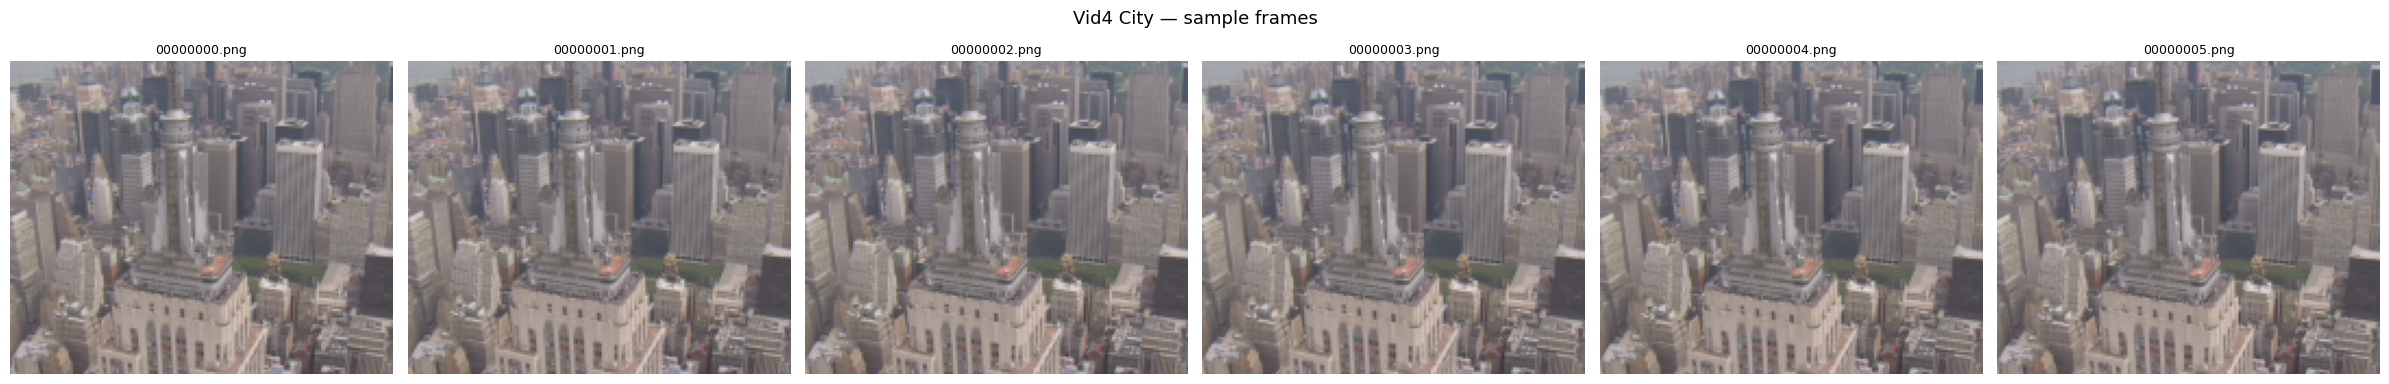

In [ ]:
#review strip
N_PREVIEW = min(6, len(frame_paths))
fig, axes = plt.subplots(1, N_PREVIEW, figsize=(4*N_PREVIEW, 4))
if N_PREVIEW == 1: axes = [axes]
for ax, p in zip(axes, frame_paths[:N_PREVIEW]):
    ax.imshow(np.array(Image.open(p).convert('RGB')))
    ax.set_title(os.path.basename(p), fontsize=9)
    ax.axis('off')
plt.suptitle('Vid4 City — sample frames', fontsize=13)
plt.tight_layout(); plt.show()


## 2. Spatial Undersampling → LR Burst

Each HR frame is centre-cropped to `PATCH_H x PATCH_W`, then bicubic-downsampled by `SCALE`. Mild Gaussian noise is added to simulate sensor noise, matching the degradation model in MFSR-GAN §3.2.

The `N_FRAMES` consecutive frames form the multi-frame burst; the middle frame is the reconstruction target.

In [ ]:
# ---- Parameters ----
SCALE     = 2       # undersampling / SR factor
N_FRAMES  = 5       # burst size (odd; middle frame = reconstruction target)
PATCH_H   = 256     # HR patch height
PATCH_W   = 256     # HR patch width
NOISE_STD = 0.01    # additive noise on LR frames (range 0-1)

def load_hr_frame(path, h=PATCH_H, w=PATCH_W):
    img = Image.open(path).convert('RGB')
    iw, ih = img.size
    if iw < w or ih < h:
        img = img.resize((max(iw, w), max(ih, h)), Image.BICUBIC)
        iw, ih = img.size
    left = (iw - w) // 2
    top  = (ih - h) // 2
    img  = img.crop((left, top, left+w, top+h))
    arr  = np.array(img).astype(np.float32) / 255.0
    return torch.from_numpy(arr).permute(2, 0, 1)   # [3, H, W]

def undersample(hr_t, scale=SCALE, noise_std=NOISE_STD):
    lr = F.interpolate(hr_t.unsqueeze(0),
                       scale_factor=1/scale,
                       mode='bicubic', antialias=True).squeeze(0)
    return (lr + noise_std * torch.randn_like(lr)).clamp(0., 1.)

# Build burst — take first N_FRAMES frames, pad if needed
chosen = frame_paths[:N_FRAMES]
if len(chosen) < N_FRAMES:
    chosen += [chosen[-1]] * (N_FRAMES - len(chosen))
    print(f"Warning: fewer than {N_FRAMES} frames; padding burst.")

hr_frames = [load_hr_frame(p).to(device) for p in chosen]
lr_frames = [undersample(f) for f in hr_frames]
hr_ref    = hr_frames[N_FRAMES // 2]
lr_ref    = lr_frames[N_FRAMES // 2]

print(f"HR frame : {hr_frames[0].shape}  [{hr_frames[0].min():.3f}, {hr_frames[0].max():.3f}]")
print(f"LR frame : {lr_frames[0].shape}  [{lr_frames[0].min():.3f}, {lr_frames[0].max():.3f}]")
print(f"Scale    : {SCALE}x  ({PATCH_H}x{PATCH_W} -> {PATCH_H//SCALE}x{PATCH_W//SCALE})")


HR frame : torch.Size([3, 256, 256])  [0.212, 0.890]
LR frame : torch.Size([3, 128, 128])  [0.234, 0.883]
Scale    : 2x  (256x256 -> 128x128)


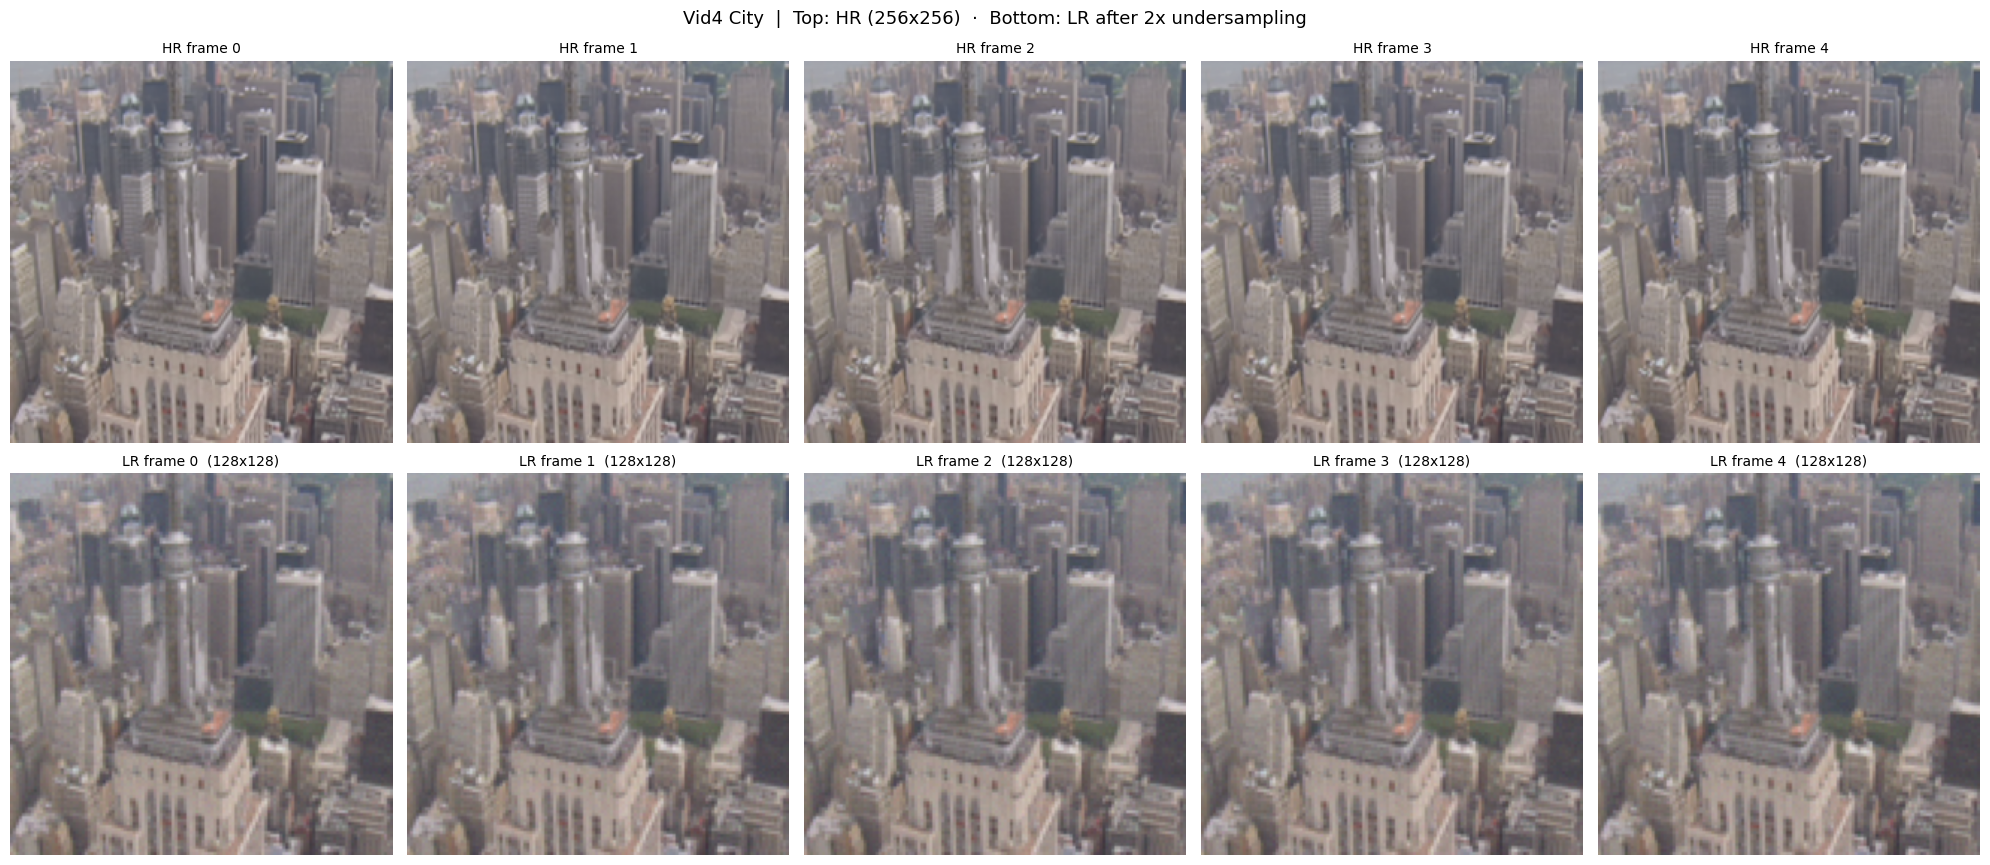

In [ ]:
# ---- Visualise HR vs LR burst ----
fig, axes = plt.subplots(2, N_FRAMES, figsize=(4*N_FRAMES, 9))
for i in range(N_FRAMES):
    axes[0,i].imshow(hr_frames[i].permute(1,2,0).cpu().numpy())
    axes[0,i].set_title(f'HR frame {i}', fontsize=10); axes[0,i].axis('off')
    axes[1,i].imshow(lr_frames[i].permute(1,2,0).cpu().numpy())
    axes[1,i].set_title(f'LR frame {i}  ({PATCH_H//SCALE}x{PATCH_W//SCALE})', fontsize=10)
    axes[1,i].axis('off')
plt.suptitle(f'Vid4 City  |  Top: HR ({PATCH_H}x{PATCH_W})  ·  Bottom: LR after {SCALE}x undersampling', fontsize=13)
plt.tight_layout(); plt.show()


Bicubic  PSNR: 34.48 dB   SSIM: 0.9253


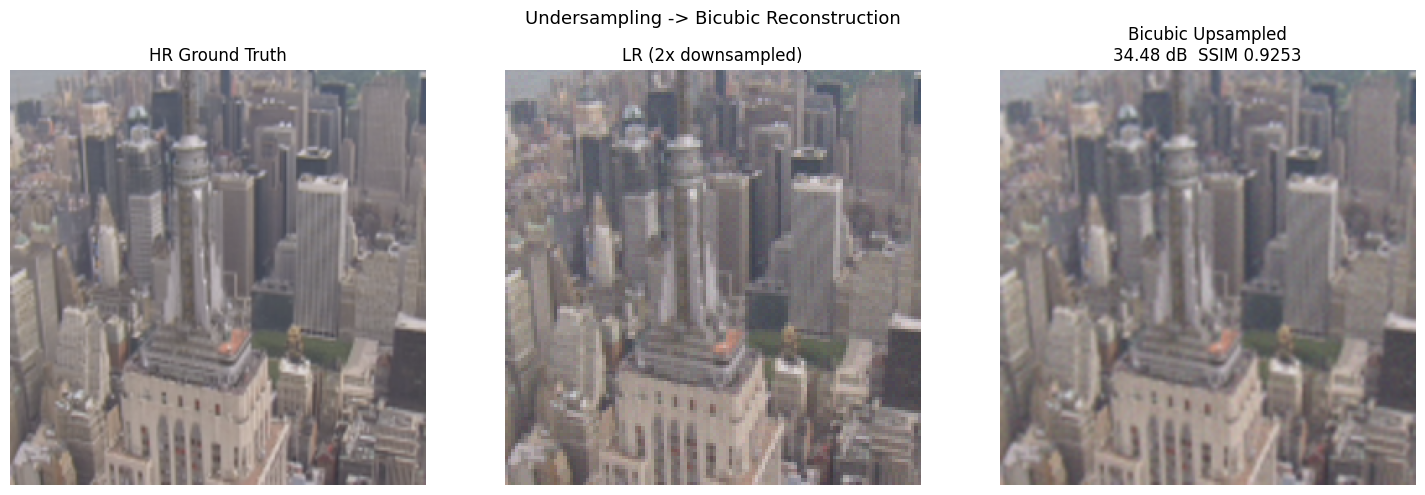

In [ ]:
# ---- Bicubic baseline ----
def bicubic_upsample(lr_t, scale):
    return F.interpolate(lr_t.unsqueeze(0), scale_factor=scale,
                         mode='bicubic', antialias=True).squeeze(0)

def psnr_torch(pred, target, max_val=1.0):
    mse = F.mse_loss(pred.clamp(0,1), target.clamp(0,1))
    return 10 * torch.log10(max_val**2 / (mse + 1e-10))

bicubic_up = bicubic_upsample(lr_ref, SCALE)
psnr_bic   = psnr_torch(bicubic_up, hr_ref)
hr_np      = hr_ref.permute(1,2,0).cpu().numpy()
bic_np     = bicubic_up.permute(1,2,0).cpu().numpy().clip(0,1)
ssim_bic   = ski_ssim(hr_np, bic_np, data_range=1.0, channel_axis=2)
print(f"Bicubic  PSNR: {psnr_bic.item():.2f} dB   SSIM: {ssim_bic:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(hr_np); axes[0].set_title('HR Ground Truth'); axes[0].axis('off')
axes[1].imshow(lr_ref.permute(1,2,0).cpu().numpy())
axes[1].set_title(f'LR ({SCALE}x downsampled)'); axes[1].axis('off')
axes[2].imshow(bic_np)
axes[2].set_title(f'Bicubic Upsampled\n{psnr_bic.item():.2f} dB  SSIM {ssim_bic:.4f}')
axes[2].axis('off')
plt.suptitle('Undersampling -> Bicubic Reconstruction', fontsize=13)
plt.tight_layout(); plt.show()


## 3. Method 1 — MFCNN (Greaves & Winter, 2016)

Bicubic-upsample all LR frames to HR size, concatenate `2d+1` adjacent frames along the channel axis, pass through a 5-layer CNN.

In [ ]:
class MFCNN(nn.Module):
    def __init__(self, d=1):
        super().__init__()
        in_ch = 3 * (2*d + 1)
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 64, 9, padding=4), nn.ReLU(inplace=True),
            nn.Conv2d(64,    32, 5, padding=2), nn.ReLU(inplace=True),
            nn.Conv2d(32,    64, 5, padding=2), nn.ReLU(inplace=True),
            nn.Conv2d(64,    32, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(32,     3, 3, padding=1),
        )
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                fan = m.in_channels*m.kernel_size[0]**2 + m.out_channels*m.kernel_size[0]**2
                nn.init.normal_(m.weight, 0, np.sqrt(2/fan))
                nn.init.zeros_(m.bias)
    def forward(self, frames_up):
        return self.net(torch.cat(frames_up, dim=1))

D = 1
mfcnn = MFCNN(d=D).to(device)
print(f"MFCNN (d={D}): {sum(p.numel() for p in mfcnn.parameters()):,} parameters")

# Bicubic-upsample all LR frames, build sliding window centred on reference
lr_up_all = [bicubic_upsample(f, SCALE) for f in lr_frames]
centre    = N_FRAMES // 2
padded    = [lr_up_all[0]]*D + lr_up_all + [lr_up_all[-1]]*D
window    = [padded[centre+D+k].unsqueeze(0) for k in range(-D, D+1)]
hr_target = hr_ref.unsqueeze(0)


MFCNN (d=1): 168,547 parameters


In [ ]:
NUM_EPOCHS_MF = 3000
opt_mf   = torch.optim.Adam(mfcnn.parameters(), lr=1e-4)
sched_mf = torch.optim.lr_scheduler.CosineAnnealingLR(opt_mf, T_max=NUM_EPOCHS_MF, eta_min=1e-6)
mf_losses = []

mfcnn.train()
for epoch in tqdm(range(NUM_EPOCHS_MF), desc="MFCNN"):
    opt_mf.zero_grad()
    out  = mfcnn(window).clamp(0, 1)
    loss = F.mse_loss(out, hr_target)
    loss.backward(); opt_mf.step(); sched_mf.step()
    mf_losses.append(loss.item())

mfcnn.eval()
with torch.no_grad():
    mf_out = mfcnn(window).clamp(0, 1).squeeze()

psnr_mf = psnr_torch(mf_out, hr_ref)
mf_np   = mf_out.permute(1,2,0).cpu().numpy()
ssim_mf = ski_ssim(hr_np, mf_np, data_range=1.0, channel_axis=2)
print(f"MFCNN  PSNR: {psnr_mf.item():.2f} dB   SSIM: {ssim_mf:.4f}   (delta {psnr_mf.item()-psnr_bic.item():+.2f} dB vs bicubic)")


MFCNN: 100%|██████████| 3000/3000 [00:16<00:00, 181.64it/s]


MFCNN  PSNR: 36.21 dB   SSIM: 0.9512   (delta +1.73 dB vs bicubic)


## 4. Method 2 — MFSR-GAN (Khan et al., CVPRW 2025)

Base-frame-centric alignment via Reference Difference Computation + deformable convolutions, channel attention multi-frame enrichment, RRDB reconstruction with pixel-shuffle ×2 upsampling, trained with relativistic GAN + L1 loss.

In [ ]:

class ChannelAttention(nn.Module):
    def __init__(self, n_feat, reduction=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Sequential(
            nn.Linear(n_feat, max(1, n_feat//reduction), bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(max(1, n_feat//reduction), n_feat, bias=False),
            nn.Sigmoid(),
        )
    def forward(self, x):
        B, C = x.shape[:2]
        return x * self.fc(self.pool(x).view(B,C)).view(B,C,1,1)

class SimpleDeformConv(nn.Module):
    def __init__(self, in_ch, out_ch, k=3):
        super().__init__()
        self.offset = nn.Conv2d(in_ch, 2, k, padding=k//2)
        self.conv   = nn.Conv2d(in_ch, out_ch, k, padding=k//2)
        nn.init.zeros_(self.offset.weight); nn.init.zeros_(self.offset.bias)
    def forward(self, x):
        B, C, H, W = x.shape
        off = self.offset(x)
        yy  = torch.linspace(-1,1,H, device=x.device)
        xx  = torch.linspace(-1,1,W, device=x.device)
        gy, gx = torch.meshgrid(yy, xx, indexing='ij')
        base = torch.stack([gx,gy],-1).unsqueeze(0).expand(B,-1,-1,-1)
        grid = (base + off.permute(0,2,3,1)/max(H,W)).clamp(-1,1)
        return self.conv(F.grid_sample(x, grid, mode='bilinear',
                                       padding_mode='border', align_corners=True))

class ResidualDenseBlock(nn.Module):
    def __init__(self, n=64, gc=32):
        super().__init__()
        self.c1  = nn.Conv2d(n,      gc, 3,1,1)
        self.c2  = nn.Conv2d(n+gc,   gc, 3,1,1)
        self.c3  = nn.Conv2d(n+2*gc,  n, 3,1,1)
        self.act = nn.LeakyReLU(0.2, inplace=True)
    def forward(self, x):
        x1 = self.act(self.c1(x))
        x2 = self.act(self.c2(torch.cat([x,x1],1)))
        return x + 0.2*self.c3(torch.cat([x,x1,x2],1))

class RRDB(nn.Module):
    def __init__(self, n=64):
        super().__init__()
        self.rdb1=ResidualDenseBlock(n); self.rdb2=ResidualDenseBlock(n); self.rdb3=ResidualDenseBlock(n)
    def forward(self, x):
        return x + 0.2*self.rdb3(self.rdb2(self.rdb1(x)))

class MFSRGenerator(nn.Module):
    def __init__(self, n_frames=5, n_feat=64, scale=2):
        super().__init__()
        self.feat_ex   = nn.Conv2d(3, n_feat, 3,1,1)
        self.align     = nn.ModuleList([SimpleDeformConv(n_feat,n_feat) for _ in range(n_frames-1)])
        self.attn      = ChannelAttention(n_feat*n_frames)
        self.reduce    = nn.Conv2d(n_feat*n_frames, n_feat, 1)
        self.rrdb      = nn.Sequential(RRDB(n_feat), RRDB(n_feat))
        self.up        = nn.Sequential(
            nn.Conv2d(n_feat, n_feat*scale**2, 3,1,1),
            nn.PixelShuffle(scale),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.out = nn.Conv2d(n_feat, 3, 3,1,1)
    def forward(self, frames):
        feats = [self.feat_ex(f) for f in frames]
        base  = feats[0]
        aln   = [base]
        for feat, ac in zip(feats[1:], self.align):
            aln.append(ac(feat - base) + base)   # RDC + ghosting skip
        fused = self.reduce(self.attn(torch.cat(aln,1)))
        rec   = self.rrdb(fused) + fused
        return self.out(self.up(rec))

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        def blk(ic,oc,s=1):
            return nn.Sequential(nn.Conv2d(ic,oc,3,s,1,bias=False),
                                 nn.BatchNorm2d(oc),nn.LeakyReLU(0.2,inplace=True))
        self.feat = nn.Sequential(
            blk(3,64),blk(64,64,2),blk(64,128),blk(128,128,2),
            blk(128,256),blk(256,256,2))
        self.cls  = nn.Sequential(
            nn.AdaptiveAvgPool2d(4),nn.Flatten(),
            nn.Linear(256*16,128),nn.LeakyReLU(0.2,True),nn.Linear(128,1))
    def forward(self,x): return self.cls(self.feat(x))

gen  = MFSRGenerator(n_frames=N_FRAMES, scale=SCALE).to(device)
disc = Discriminator().to(device)
print(f"Generator    : {sum(p.numel() for p in gen.parameters()):,} parameters")
print(f"Discriminator: {sum(p.numel() for p in disc.parameters()):,} parameters")


Generator    : 1,056,523 parameters
Discriminator: 1,670,849 parameters


In [ ]:
#MFSR-GAN training
def rel_gen_loss(f, r):
    mf,mr = f.mean(),r.mean()
    return (-torch.log(torch.sigmoid(r-mf)+1e-8)
            -torch.log(1-torch.sigmoid(f-mr)+1e-8)).mean()

def rel_disc_loss(f, r):
    mf,mr = f.mean(),r.mean()
    return (-torch.log(torch.sigmoid(r-mf)+1e-8)
            -torch.log(1-torch.sigmoid(f-mr)+1e-8)).mean()

opt_g   = torch.optim.Adam(gen.parameters(),  lr=5e-4, betas=(0.9,0.999))
opt_d   = torch.optim.Adam(disc.parameters(), lr=5e-4, betas=(0.9,0.999))
sched_g = torch.optim.lr_scheduler.CosineAnnealingLR(opt_g, T_max=2000, eta_min=5e-6)
sched_d = torch.optim.lr_scheduler.CosineAnnealingLR(opt_d, T_max=2000, eta_min=5e-6)

lr_batch = [f.unsqueeze(0) for f in lr_frames]
hr_batch = hr_ref.unsqueeze(0)

LAMBDA_L1, LAMBDA_GAN = 1.0, 1e-2
NUM_EPOCHS_GAN = 2000
gan_g_losses, gan_d_losses = [], []

gen.train(); disc.train()
for epoch in tqdm(range(NUM_EPOCHS_GAN), desc="MFSR-GAN"):
    opt_d.zero_grad()
    with torch.no_grad():
        fake = gen(lr_batch).clamp(0,1)
    loss_d = rel_disc_loss(disc(fake.detach()), disc(hr_batch))
    loss_d.backward(); opt_d.step()

    opt_g.zero_grad()
    fake   = gen(lr_batch).clamp(0,1)
    l1     = F.l1_loss(fake, hr_batch)
    gloss  = rel_gen_loss(disc(fake), disc(hr_batch).detach())
    loss_g = LAMBDA_L1*l1 + LAMBDA_GAN*gloss
    loss_g.backward(); opt_g.step()
    sched_g.step(); sched_d.step()
    gan_g_losses.append(loss_g.item())
    gan_d_losses.append(loss_d.item())

gen.eval()
with torch.no_grad():
    gan_out = gen(lr_batch).clamp(0,1).squeeze()

psnr_gan = psnr_torch(gan_out, hr_ref)
gan_np   = gan_out.permute(1,2,0).cpu().numpy()
ssim_gan = ski_ssim(hr_np, gan_np, data_range=1.0, channel_axis=2)
print(f"MFSR-GAN  PSNR: {psnr_gan.item():.2f} dB   SSIM: {ssim_gan:.4f}   (delta {psnr_gan.item()-psnr_bic.item():+.2f} dB vs bicubic)")


MFSR-GAN: 100%|██████████| 2000/2000 [02:08<00:00, 15.61it/s]


MFSR-GAN  PSNR: 38.66 dB   SSIM: 0.9729   (delta +4.18 dB vs bicubic)


## 5. Results

In [ ]:
# summary
print('='*62)
print(f"{'Method':<22} {'PSNR (dB)':>10} {'SSIM':>8} {'delta Bic':>10}")
print('-'*62)
for name, pv, sv in [
    ('Bicubic',      psnr_bic.item(),  ssim_bic),
    ('MFCNN (d=1)',  psnr_mf.item(),   ssim_mf),
    ('MFSR-GAN',     psnr_gan.item(),  ssim_gan),
]:
    print(f"{name:<22} {pv:>10.2f} {sv:>8.4f} {pv-psnr_bic.item():>+10.2f}")
print('='*62)


Method                  PSNR (dB)     SSIM  delta Bic
--------------------------------------------------------------
Bicubic                     34.48   0.9253      +0.00
MFCNN (d=1)                 36.21   0.9512      +1.73
MFSR-GAN                    38.66   0.9729      +4.18


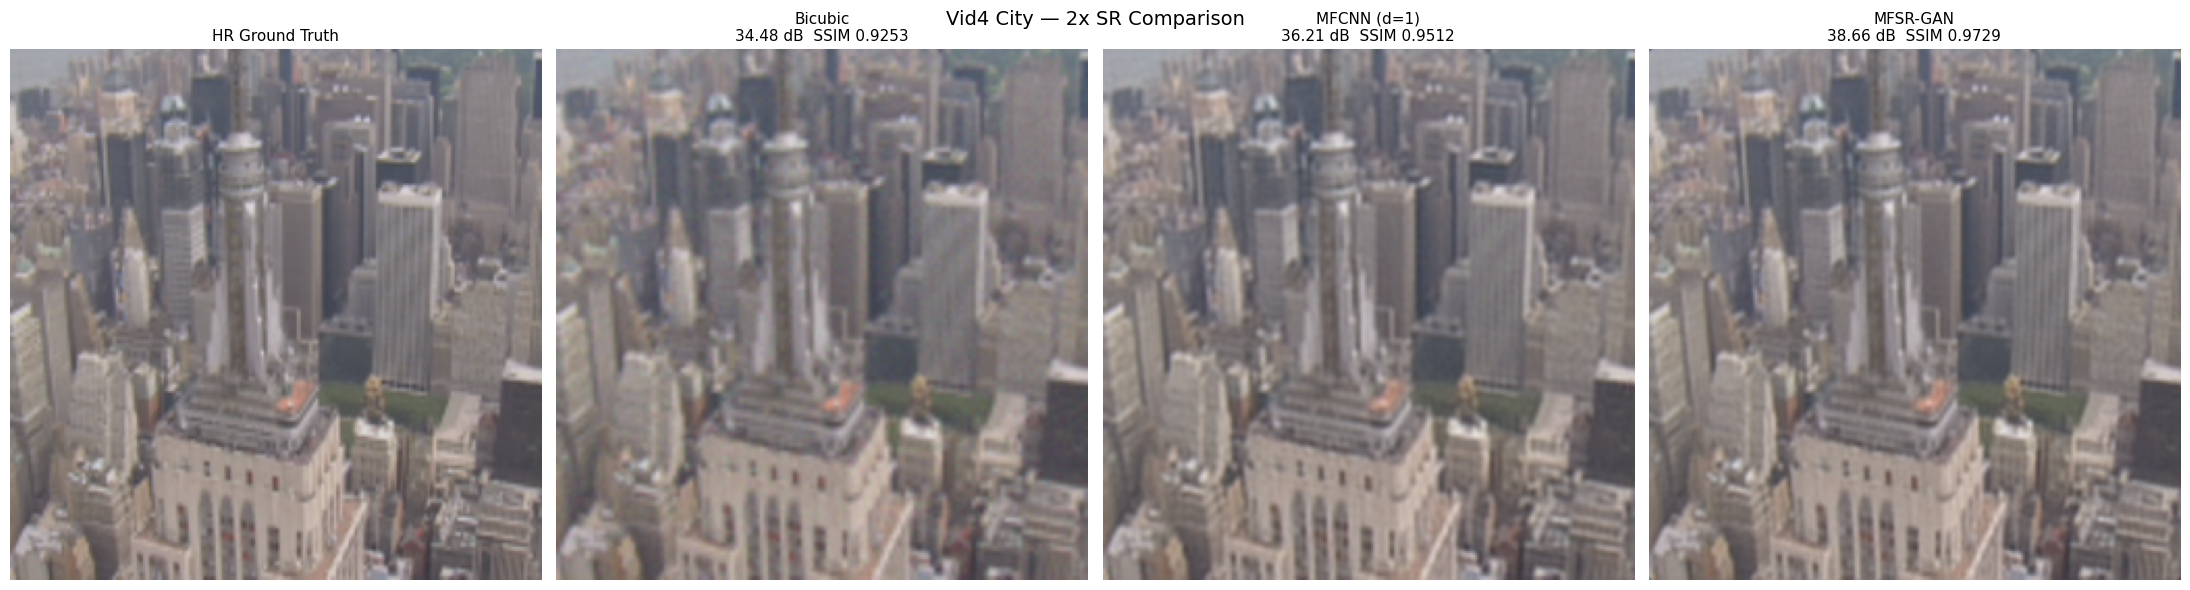

In [ ]:
#Visual comparison
imgs   = [hr_ref, bicubic_up, mf_out, gan_out]
labels = [
    'HR Ground Truth',
    f'Bicubic\n{psnr_bic.item():.2f} dB  SSIM {ssim_bic:.4f}',
    f'MFCNN (d=1)\n{psnr_mf.item():.2f} dB  SSIM {ssim_mf:.4f}',
    f'MFSR-GAN\n{psnr_gan.item():.2f} dB  SSIM {ssim_gan:.4f}',
]
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
for ax, img, lbl in zip(axes, imgs, labels):
    ax.imshow(img.permute(1,2,0).cpu().numpy().clip(0,1))
    ax.set_title(lbl, fontsize=11); ax.axis('off')
plt.suptitle(f'Vid4 City — {SCALE}x SR Comparison', fontsize=14)
plt.tight_layout(); plt.show()


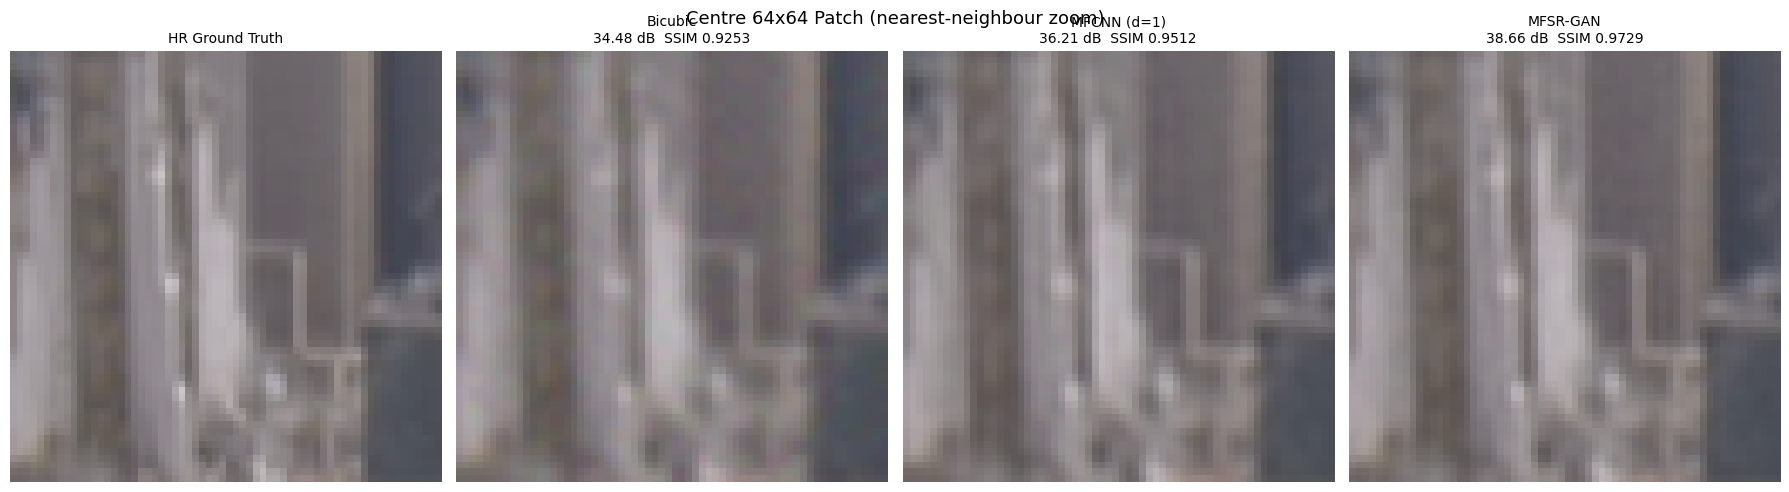

In [ ]:
# ---- Zoomed patch (64x64 centre crop) ----
ph, pw = 64, 64
ch, cw = PATCH_H//2, PATCH_W//2
slh = slice(ch-ph//2, ch+ph//2)
slw = slice(cw-pw//2, cw+pw//2)
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, img, lbl in zip(axes, imgs, labels):
    patch = img.permute(1,2,0).cpu().numpy().clip(0,1)[slh, slw]
    ax.imshow(patch, interpolation='nearest')
    ax.set_title(lbl, fontsize=10); ax.axis('off')
plt.suptitle(f'Centre {ph}x{pw} Patch (nearest-neighbour zoom)', fontsize=13)
plt.tight_layout(); plt.show()


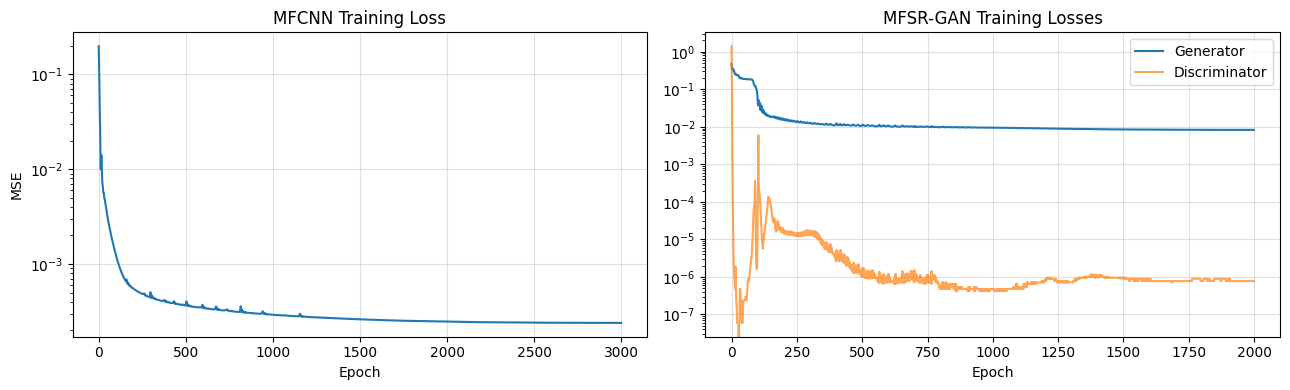

In [ ]:
# ---- Training curves ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.semilogy(mf_losses); ax1.set_title('MFCNN Training Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('MSE'); ax1.grid(True, alpha=0.4)
ax2.semilogy(gan_g_losses, label='Generator')
ax2.semilogy(gan_d_losses, label='Discriminator', alpha=0.7)
ax2.set_title('MFSR-GAN Training Losses')
ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()
